In [ ]:
import zipfile
import os

zip_path = "/content/daily+and+sports+activities.zip"
extract_path = "/content/DASD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['data']


In [ ]:
import os
import numpy as np

dataset_path = "/content/DASD/data"

# activities
activities = sorted(os.listdir(dataset_path))
print("Activities:", activities)

# first activity
activity = activities[0]

activity_path = os.path.join(dataset_path, activity)

# participants
participants = sorted(os.listdir(activity_path))
print("Participants:", participants)

# first participant
participant = participants[0]

participant_path = os.path.join(activity_path, participant)

# files
files = sorted(os.listdir(participant_path))
print("Files:", files[:5])

# first sample
sample_file = os.path.join(participant_path, files[0])

signal = np.loadtxt(sample_file, delimiter=',')

print("\nSample File:", sample_file)
print("Shape:", signal.shape)

print("\nFirst 5 rows:")
print(signal[:5])

Activities: ['a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08', 'a09', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'a19']
Participants: ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8']
Files: ['s01.txt', 's02.txt', 's03.txt', 's04.txt', 's05.txt']

Sample File: /content/DASD/data/a01/p1/s01.txt
Shape: (125, 45)

First 5 rows:
[[ 8.1305e+00  1.0349e+00  5.4217e+00 -9.4610e-03  1.9150e-03 -3.4240e-03
  -7.8712e-01 -6.9654e-02  1.5730e-01  7.0097e-01  5.6829e+00  7.9812e+00
   3.8760e-03 -5.2130e-03 -1.1680e-03 -5.7285e-01 -5.5907e-01 -2.1226e-01
   3.4193e+00 -8.3416e+00  3.8627e+00 -5.1550e-03 -8.4370e-03 -1.5600e-02
  -6.4769e-01  3.4136e-01  7.3549e-02 -3.5160e+00  9.0513e+00 -9.3283e-01
   4.7340e-03  7.9490e-03 -1.3605e-02  7.2985e-01 -2.5366e-01 -3.6453e-02
  -2.8071e+00 -9.0812e+00  2.6220e+00 -2.3200e-04 -1.2092e-02 -4.4570e-03
   7.4017e-01  3.0053e-01 -5.7730e-02]
 [ 8.1305e+00  1.0202e+00  5.3843e+00 -9.3680e-03  2.3485e-02  1.9530e-03
  -7.8717e-01 -6.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# normalize each channel independently
scaler = MinMaxScaler(feature_range=(-1, 1))

normalized_sample = scaler.fit_transform(signal)

print("Normalized Shape:", normalized_sample.shape)

print("Minimum Value:", normalized_sample.min())
print("Maximum Value:", normalized_sample.max())

print("\nFirst 5 rows:")
print(normalized_sample[:5])

Normalized Shape: (125, 45)
Minimum Value: -1.0
Maximum Value: 1.0000000000000009

First 5 rows:
[[ 0.87452949 -0.59668389 -0.75754772 -0.29393175 -0.44106784  0.17883023
   0.64292683 -0.46659289  0.925       0.32907752 -0.30906213  0.75530587
  -0.31956858 -0.24558315  0.31479582 -0.04089332  0.17361111  0.07709899
   0.37802098  0.48363252  0.07271306  0.2251917  -0.128398   -0.19959974
   0.10126582 -0.04785276  0.33009248  0.34772897 -0.30769231  0.12995193
   0.3378875  -0.03949166 -0.45984621 -0.14611872 -0.91099476 -0.07213851
   0.00750626 -0.08100147  0.03350254  0.2064236  -0.63970123 -0.03285374
   0.09053498 -0.54545455 -0.29359514]
 [ 0.87452949 -0.75495263 -0.84407172 -0.2917384  -0.29502808  0.41075742
   0.63317073 -0.08507401  0.98951613  0.52829538 -0.96121884  0.63046192
   0.01930837 -0.2472831   0.24410256 -0.04723102  0.34567901  0.04148971
   0.5120839   0.17529039 -0.06802189 -0.04932399  0.10110905  0.20077031
  -0.18987342  0.20736196  0.64216267  0.01116902 

In [ ]:
!pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.7 MB/s eta 0:00:00


In [ ]:
from pyts.image import GramianAngularField
import numpy as np

# create GASF transformer
gasf = GramianAngularField(method='summation')

num_channels = normalized_sample.shape[1]

gasf_images = []

for ch in range(num_channels):

    signal = normalized_sample[:, ch]

    signal = signal.reshape(1, -1)

    gasf_image = gasf.fit_transform(signal)

    gasf_image = gasf_image[0]

    gasf_images.append(gasf_image)

# stack all 45 channels
gasf_tensor = np.stack(gasf_images, axis=-1)

print("GASF Tensor Shape:", gasf_tensor.shape)

GASF Tensor Shape: (125, 125, 45)


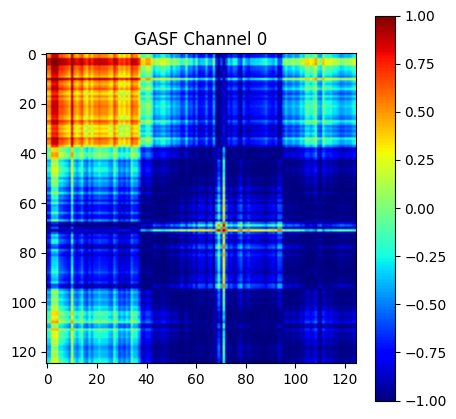

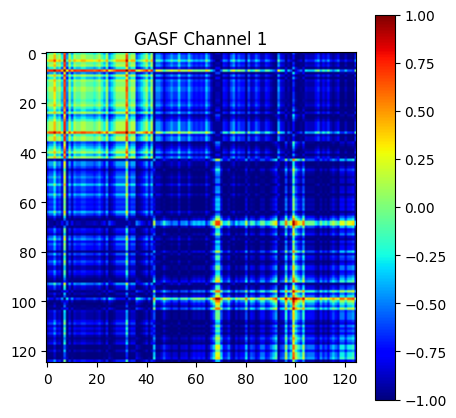

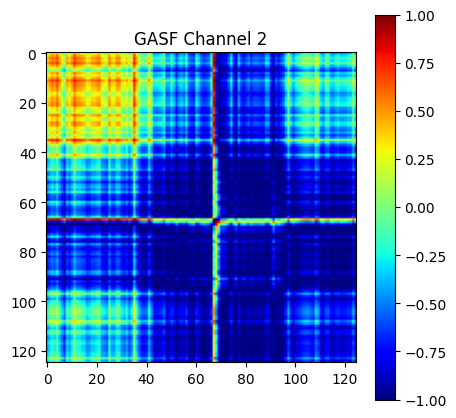

In [ ]:
import matplotlib.pyplot as plt

for ch in range(3):

    plt.figure(figsize=(5,5))

    plt.imshow(
        gasf_tensor[:, :, ch],
        cmap="jet"
    )

    plt.title(f"GASF Channel {ch}")

    plt.colorbar()

    plt.show()

In [ ]:
import os
import numpy as np
from pyts.image import GramianAngularField
from sklearn.preprocessing import MinMaxScaler

dataset_path = "/content/DASD/data"
save_path = "/content/GASF_DATA"

os.makedirs(save_path, exist_ok=True)

gasf = GramianAngularField(method='summation')

activities = sorted(os.listdir(dataset_path))

sample_count = 0

print("Starting GASF generation...\n")

for activity in activities:

    activity_path = os.path.join(dataset_path, activity)

    participants = sorted(os.listdir(activity_path))

    for participant in participants:

        participant_path = os.path.join(activity_path, participant)

        files = sorted(os.listdir(participant_path))

        for file in files:

            file_path = os.path.join(participant_path, file)

            # load signal
            signal_data = np.loadtxt(
                file_path,
                delimiter=','
            )

            # normalize
            scaler = MinMaxScaler(
                feature_range=(-1, 1)
            )

            normalized_signal = scaler.fit_transform(
                signal_data
            )

            gasf_channels = []

            for ch in range(normalized_signal.shape[1]):

                signal = normalized_signal[:, ch]

                signal = signal.reshape(1, -1)

                gasf_image = gasf.fit_transform(signal)[0]

                gasf_channels.append(gasf_image)

            gasf_tensor = np.stack(
                gasf_channels,
                axis=-1
            )

            save_name = (
                f"{activity}_{participant}_{file[:-4]}.npy"
            )

            save_file = os.path.join(
                save_path,
                save_name
            )

            np.save(
                save_file,
                gasf_tensor.astype(np.float32)
            )

            sample_count += 1

    print(f"Finished: {activity}")

print("\nGASF Generation Complete!")
print("Total Samples:", sample_count)

Starting GASF generation...

Finished: a01
Finished: a02
Finished: a03
Finished: a04
Finished: a05
Finished: a06
Finished: a07
Finished: a08
Finished: a09
Finished: a10
Finished: a11
Finished: a12
Finished: a13
Finished: a14
Finished: a15
Finished: a16
Finished: a17
Finished: a18
Finished: a19

GASF Generation Complete!
Total Samples: 9120


In [ ]:
import os

data_path = "/content/GASF_DATA"

all_files = sorted(os.listdir(data_path))

print("Total Files:", len(all_files))

file_paths = []
labels = []

for file in all_files:

    file_path = os.path.join(data_path, file)

    # a01_p1_s01.npy -> label 0
    activity = file.split("_")[0]

    label = int(activity[1:]) - 1

    file_paths.append(file_path)
    labels.append(label)

print("\nExample File:")
print(file_paths[0])

print("\nExample Label:")
print(labels[0])

Total Files: 9120

Example File:
/content/GASF_DATA/a01_p1_s01.npy

Example Label:
0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 7296
Testing Samples : 1824


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class GASFDataset(Dataset):

    def __init__(self, file_paths, labels):

        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):

        return len(self.file_paths)

    def __getitem__(self, idx):

        # load GASF tensor
        x = np.load(self.file_paths[idx])

        # (125,125,45) -> (45,125,125)
        x = np.transpose(x, (2, 0, 1))

        x = torch.tensor(
            x,
            dtype=torch.float32
        )

        y = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return x, y

In [ ]:
train_dataset = GASFDataset(
    X_train,
    y_train
)

test_dataset = GASFDataset(
    X_test,
    y_test
)

print("Train Dataset:", len(train_dataset))
print("Test Dataset :", len(test_dataset))

Train Dataset: 7296
Test Dataset : 1824


In [ ]:
sample_x, sample_y = train_dataset[0]

print("Input Shape:", sample_x.shape)
print("Label:", sample_y)

Input Shape: torch.Size([45, 125, 125])
Label: tensor(18)


In [ ]:
batch_x, batch_y = next(iter(train_loader))

print("Batch Shape:", batch_x.shape)
print("Labels Shape:", batch_y.shape)

Batch Shape: torch.Size([8, 45, 125, 125])
Labels Shape: torch.Size([8])


In [ ]:
import torch
import torch.nn as nn
import timm
import numpy as np


# ---------------- Fixed 2D Sin-Cos Positional Embedding ---------------- #

def get_1d_sincos_pos_embed(embed_dim, pos):

    omega = np.arange(embed_dim // 2, dtype=np.float32)
    omega /= embed_dim / 2.
    omega = 1. / (10000 ** omega)

    pos = pos.reshape(-1)

    out = np.einsum('m,d->md', pos, omega)

    return np.concatenate(
        [np.sin(out), np.cos(out)],
        axis=1
    )


def get_2d_sincos_pos_embed_from_grid(embed_dim, grid):

    emb_h = get_1d_sincos_pos_embed(
        embed_dim // 2,
        grid[0]
    )

    emb_w = get_1d_sincos_pos_embed(
        embed_dim // 2,
        grid[1]
    )

    return np.concatenate(
        [emb_h, emb_w],
        axis=1
    )


def get_2d_sincos_pos_embed(embed_dim, grid_size):

    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)

    grid = np.meshgrid(grid_w, grid_h)
    grid = np.stack(grid, axis=0)

    grid = grid.reshape([2, 1, grid_size, grid_size])

    pos_embed = get_2d_sincos_pos_embed_from_grid(
        embed_dim,
        grid
    )

    return torch.from_numpy(pos_embed).float()


# ---------------- DASD SimpleViT ---------------- #

class SimpleViT19Class(nn.Module):

    def __init__(
        self,
        image_size=128,
        patch_size=16,
        in_channels=45
    ):

        super().__init__()

        self.num_classes = 19

        self.vit = timm.create_model(
            "vit_base_patch16_224",
            pretrained=True,
            num_classes=0,
            drop_rate=0.1,
            drop_path_rate=0.1
        )

        # Modify input channels
        old = self.vit.patch_embed.proj

        self.vit.patch_embed.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=old.out_channels,
            kernel_size=old.kernel_size,
            stride=old.stride,
            padding=old.padding,
            bias=(old.bias is not None)
        )

        with torch.no_grad():

            self.vit.patch_embed.proj.weight.zero_()

            self.vit.patch_embed.proj.weight[:, :3] = old.weight

            if old.bias is not None:
                self.vit.patch_embed.proj.bias.copy_(old.bias)

        # Remove CLS token
        self.vit.cls_token = None
        self.vit.num_tokens = 0

        # Fixed positional embedding
        grid_size = image_size // patch_size

        embed_dim = self.vit.embed_dim

        pos_embed = get_2d_sincos_pos_embed(
            embed_dim,
            grid_size
        )

        self.register_buffer(
            "pos_embed",
            pos_embed.unsqueeze(0),
            persistent=False
        )

        # Classification head
        self.head = nn.Linear(
            embed_dim,
            self.num_classes
        )

        self.vit.patch_embed.img_size = (
            image_size,
            image_size
        )

        self.vit.patch_embed.strict_img_size = False

    def forward(self, x):

        x = self.vit.patch_embed(x)

        # Compatible with different timm versions
        if x.ndim == 4:
            x = x.flatten(2).transpose(1, 2)

        x = x + self.pos_embed

        x = self.vit.pos_drop(x)

        for blk in self.vit.blocks:
            x = blk(x)

        x = self.vit.norm(x)

        # Global Average Pooling
        x = x.mean(dim=1)

        x = self.head(x)

        return x

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleViT19Class(
    image_size=125,
    patch_size=16,
    in_channels=45
).to(device)

print("Model created!")

Model created!


In [ ]:
model = SimpleViT19Class(
    image_size=128,
    patch_size=16,
    in_channels=45
).to(device)

In [ ]:
print("pos_embed shape:", model.pos_embed.shape)

x = torch.randn(2, 45, 128, 128).to(device)

patches = model.vit.patch_embed(x)

print("patch_embed output:", patches.shape)

patches = patches.flatten(2).transpose(1, 2)

print("tokens shape:", patches.shape)

pos_embed shape: torch.Size([1, 64, 768])
patch_embed output: torch.Size([2, 64, 768])
tokens shape: torch.Size([2, 768, 64])


In [ ]:
x = torch.randn(
    2,
    45,
    128,
    128
).to(device)

out = model(x)

print("Output Shape:", out.shape)

Output Shape: torch.Size([2, 19])


In [ ]:
import os
import numpy as np
from pyts.image import GramianAngularField
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import zoom

dataset_path = "/content/DASD/data"
save_path = "/content/GASF128_DATA"

os.makedirs(save_path, exist_ok=True)

gasf = GramianAngularField(method='summation')

sample_count = 0

activities = sorted(os.listdir(dataset_path))

for activity in activities:

    activity_path = os.path.join(dataset_path, activity)

    participants = sorted(os.listdir(activity_path))

    for participant in participants:

        participant_path = os.path.join(
            activity_path,
            participant
        )

        files = sorted(os.listdir(participant_path))

        for file in files:

            file_path = os.path.join(
                participant_path,
                file
            )

            signal_data = np.loadtxt(
                file_path,
                delimiter=','
            )

            scaler = MinMaxScaler(
                feature_range=(-1, 1)
            )

            normalized_signal = scaler.fit_transform(
                signal_data
            )

            gasf_channels = []

            for ch in range(
                normalized_signal.shape[1]
            ):

                signal = normalized_signal[:, ch]

                signal = signal.reshape(1, -1)

                gasf_image = gasf.fit_transform(
                    signal
                )[0]

                # resize 125 -> 128
                gasf_image = zoom(
                    gasf_image,
                    (128/125, 128/125),
                    order=1
                )

                gasf_channels.append(
                    gasf_image
                )

            gasf_tensor = np.stack(
                gasf_channels,
                axis=-1
            )

            save_name = (
                f"{activity}_{participant}_{file[:-4]}.npy"
            )

            np.save(
                os.path.join(
                    save_path,
                    save_name
                ),
                gasf_tensor.astype(
                    np.float32
                )
            )

            sample_count += 1

    print(f"Finished {activity}")

print("\nTotal Samples:", sample_count)

Finished a01
Finished a02
Finished a03
Finished a04
Finished a05
Finished a06
Finished a07
Finished a08
Finished a09
Finished a10
Finished a11
Finished a12
Finished a13
Finished a14
Finished a15
Finished a16
Finished a17
Finished a18
Finished a19

Total Samples: 9120


In [ ]:
import os

data_path = "/content/GASF128_DATA"

all_files = sorted(os.listdir(data_path))

file_paths = []
labels = []

for file in all_files:

    file_path = os.path.join(data_path, file)

    activity = file.split("_")[0]

    label = int(activity[1:]) - 1

    file_paths.append(file_path)
    labels.append(label)

print("Total Files:", len(file_paths))
print("Example:", file_paths[0])
print("Label:", labels[0])

Total Files: 9120
Example: /content/GASF128_DATA/a01_p1_s01.npy
Label: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 7296
Test : 1824


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class GASF128Dataset(Dataset):

    def __init__(self, file_paths, labels):

        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):

        return len(self.file_paths)

    def __getitem__(self, idx):

        x = np.load(self.file_paths[idx])

        # (128,128,45) -> (45,128,128)
        x = np.transpose(x, (2, 0, 1))

        x = torch.tensor(
            x,
            dtype=torch.float32
        )

        y = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return x, y

In [ ]:
train_dataset = GASF128Dataset(
    X_train,
    y_train
)

test_dataset = GASF128Dataset(
    X_test,
    y_test
)

print("Train:", len(train_dataset))
print("Test :", len(test_dataset))

Train: 7296
Test : 1824


In [ ]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
batch_x, batch_y = next(iter(train_loader))

print(batch_x.shape)
print(batch_y.shape)

torch.Size([8, 45, 128, 128])
torch.Size([8])


In [ ]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=15
)

print("Training setup complete!")

Training setup complete!


In [ ]:
from tqdm import tqdm
import torch

num_epochs = 15

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        accuracy = 100. * correct / total

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{accuracy:.2f}"
        )

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100. * correct / total

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {epoch_acc:.2f}%")

100%|██████████| 912/912 [02:10<00:00,  7.00it/s, accuracy=34.46, loss=0.3055]



Epoch 1/15
Train Loss: 2.0092
Train Accuracy: 34.46%


100%|██████████| 912/912 [02:01<00:00,  7.53it/s, accuracy=71.64, loss=0.7720]



Epoch 2/15
Train Loss: 0.7506
Train Accuracy: 71.64%


100%|██████████| 912/912 [02:01<00:00,  7.48it/s, accuracy=83.53, loss=0.1691]


...


Epoch 13/15
Train Loss: 0.0003
Train Accuracy: 100.00%


100%|██████████| 912/912 [02:06<00:00,  7.22it/s, accuracy=99.99, loss=0.0004]



Epoch 14/15
Train Loss: 0.0005
Train Accuracy: 99.99%


100%|██████████| 912/912 [02:13<00:00,  6.82it/s, accuracy=100.00, loss=0.0000]


Epoch 15/15
Train Loss: 0.0003
Train Accuracy: 100.00%


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

Accuracy : 0.9243421052631579
Precision: 0.9256074969145102
Recall   : 0.9243421052631579
F1 Score : 0.9242463043327341


In [ ]:
torch.save(
    model.state_dict(),
    "simplevit_gasf_dasd.pth"
)

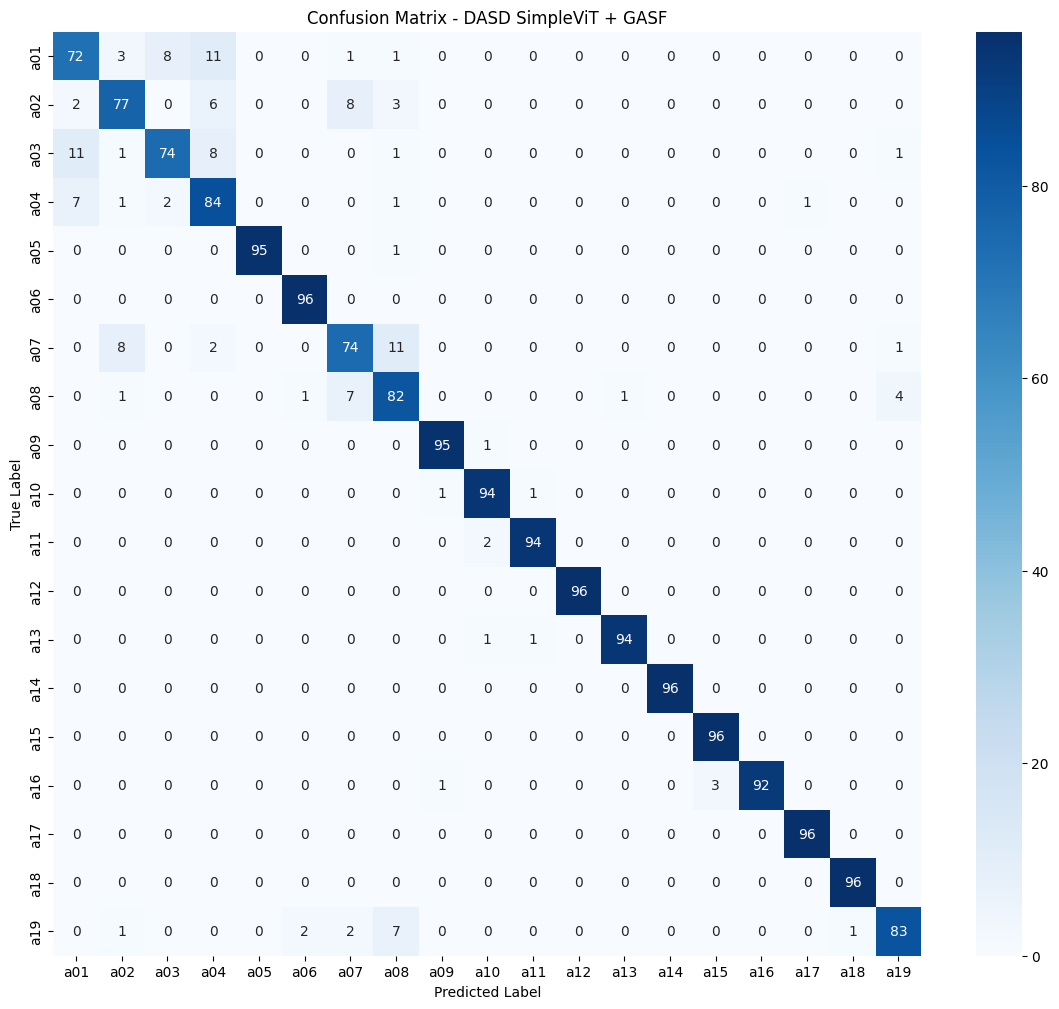

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cm = confusion_matrix(y_true, y_pred)

classes = [f"a{i:02d}" for i in range(1, 20)]

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - DASD SimpleViT + GASF")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()